# Crop Recommendation System — End-to-End Machine Learning Project

**Student:** Akhilesh
**Program:** B.Tech, Artificial Intelligence & Machine Learning
**Dataset:** Crop Recommendation Dataset (`Crop_recommendation.csv`)

## 1. Problem Statement

Farmers often struggle to decide which crop is best suited to their field, given the soil nutrient levels and prevailing climate. This project builds a **multiclass classification model** that recommends the most suitable crop to grow, based on:

- Soil nutrients: Nitrogen (N), Phosphorus (P), Potassium (K)
- Climate conditions: Temperature (°C), Humidity (%), Rainfall (mm)
- Soil pH

**Target variable:** `label` — the crop name (22 possible crops).

This is a supervised, **multiclass classification** problem (not regression), since the output is a categorical crop name.


In [1]:
# 1.1 Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42


## 2. Load and Understand the Dataset

We load the CSV file and inspect its shape, data types, and basic statistics to understand what we're working with before doing anything else.

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


**Observation:** The dataset has 2200 rows and 8 columns — 7 numeric features (`N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`) and 1 categorical target (`label`). All features are continuous/numeric, so no categorical encoding is needed for the inputs.

## 3. Data Cleaning — Missing Values, Duplicates, Outliers

### 3.1 Missing values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0


**Observation:** There are no missing values in the dataset, so no imputation is required.

### 3.2 Duplicate rows

In [6]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)


Number of duplicate rows: 0


### 3.3 Class balance

Since this is a classification problem, checking whether classes are balanced tells us whether we need techniques like class weighting or resampling.

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


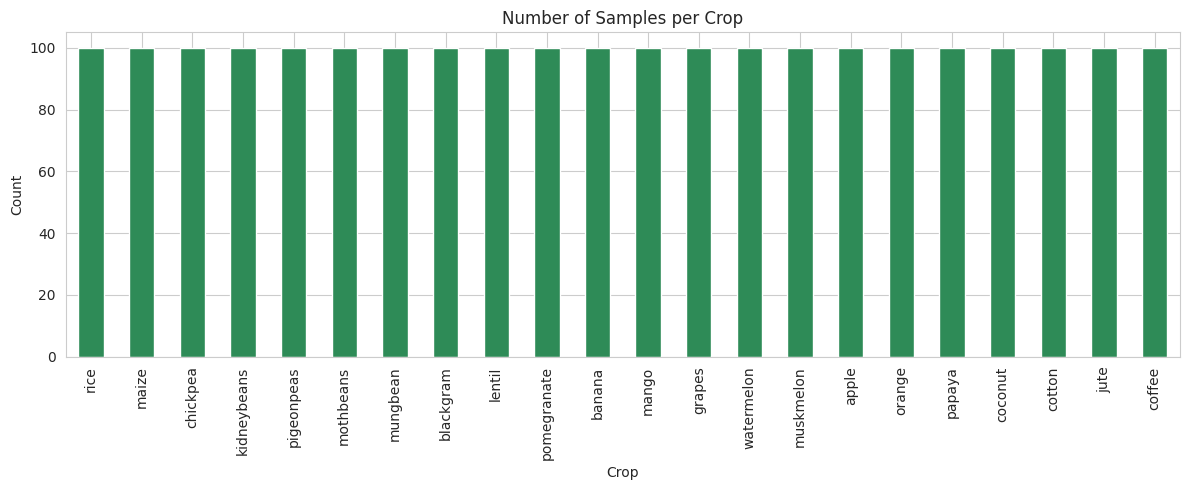

In [7]:
print(df['label'].value_counts())

plt.figure(figsize=(12, 5))
df['label'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Number of Samples per Crop')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** The dataset is perfectly balanced — exactly 100 samples for each of the 22 crops. This means we do **not** need class balancing techniques (like SMOTE or class weights), and accuracy is a reliable evaluation metric here (it would not be reliable on an imbalanced dataset).

### 3.4 Outlier check

We use boxplots and the IQR method to look for outliers in each numeric feature.

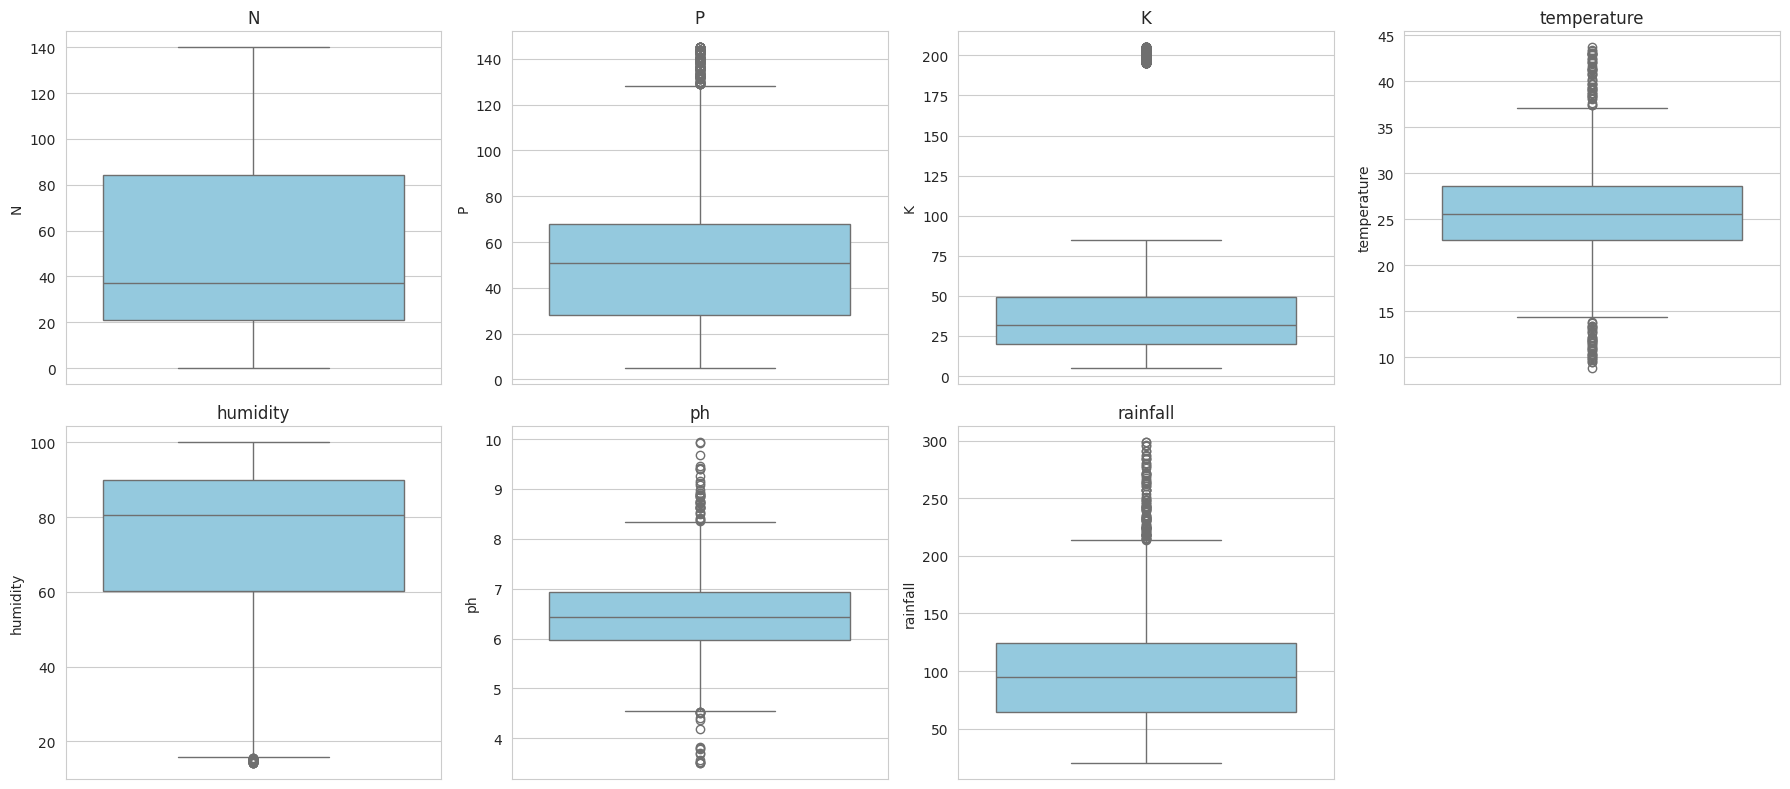

In [8]:
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [9]:
# Quantify outliers using IQR method (global, across all crops combined)
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

pd.Series(outlier_summary, name='outlier_count')


N                0
P              138
K              200
temperature     86
humidity        30
ph              57
rainfall       100
Name: outlier_count, dtype: int64

**Decision on outliers:** A few features (like `ph` and `rainfall`) show points flagged as outliers by the global IQR rule. However, this dataset naturally clusters by crop — e.g., rice genuinely needs much higher rainfall than mothbeans, and this is a real agronomic difference, not measurement error. Removing these points would delete legitimate crop-specific patterns and hurt the model's ability to distinguish crops. So we **do not remove any rows as outliers** here — the extreme-looking values are informative, not noisy.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Feature correlation

Checking correlation helps us see if any features are redundant (highly correlated with each other).

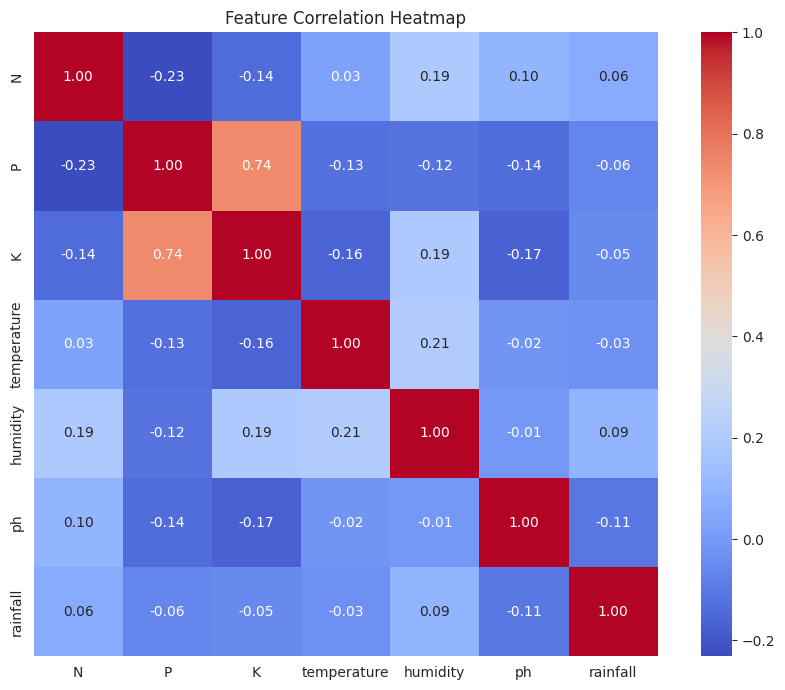

In [10]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


**Observation:** Phosphorus (`P`) and Potassium (`K`) show a moderate positive correlation, and most other feature pairs are weakly correlated. No pair is correlated strongly enough (e.g., > 0.9) to justify dropping a feature — all 7 features carry distinct information, so we keep all of them.

### 4.2 Feature distributions by crop (sample)

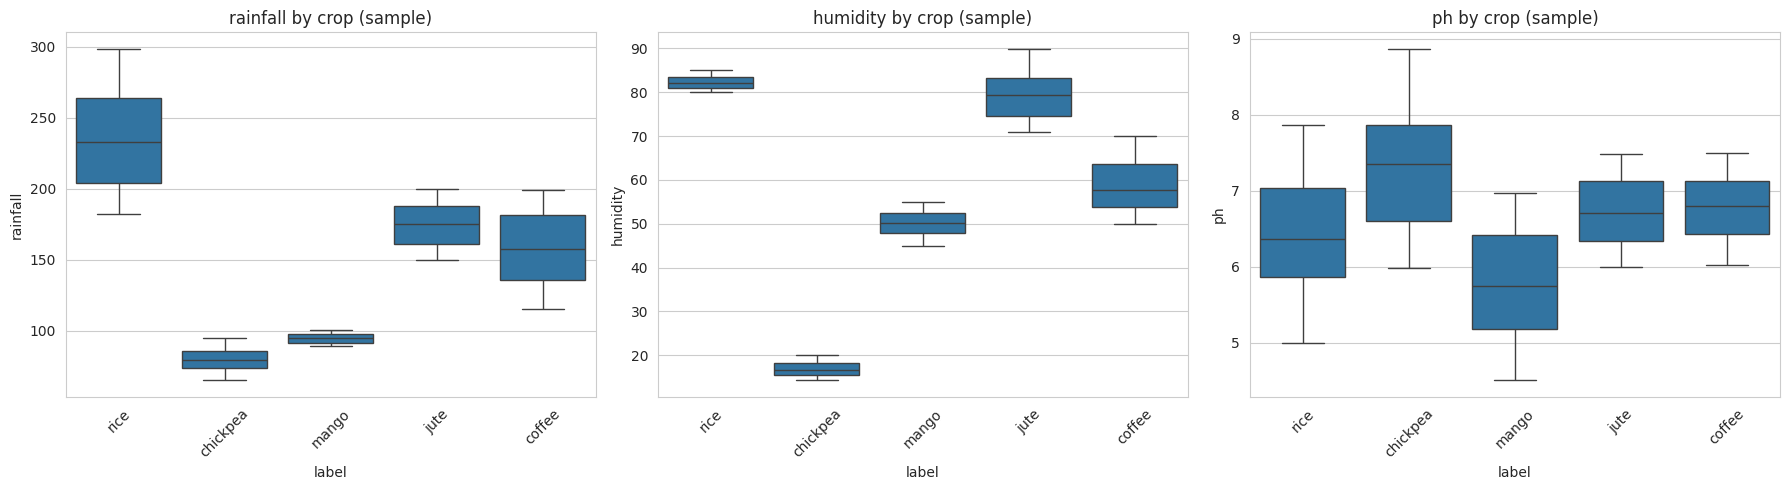

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_crops = ['rice', 'jute', 'coffee', 'mango', 'chickpea']
for ax, feat in zip(axes, ['rainfall', 'humidity', 'ph']):
    sns.boxplot(data=df[df['label'].isin(sample_crops)], x='label', y=feat, ax=ax)
    ax.set_title(f'{feat} by crop (sample)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Different crops occupy clearly different ranges for rainfall, humidity, and pH (e.g., rice needs high rainfall and humidity; chickpea tolerates a different pH range). This confirms that these features are genuinely predictive of the crop label, which is encouraging for building a classifier.

## 5. Feature Engineering

All 7 input features are already numeric, meaningful, and (as shown above) predictive — there are no categorical variables to encode and no obviously redundant features to drop. As a light-touch feature engineering step, we derive one extra ratio feature (`N_P_ratio`) that can help models capture the balance between nutrients rather than just their raw amounts, then compare performance with and without it.

In [12]:
df_fe = df.copy()
df_fe['N_P_ratio'] = df_fe['N'] / (df_fe['P'] + 1e-6)

feature_cols_base = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
feature_cols_fe = feature_cols_base + ['N_P_ratio']

df_fe[feature_cols_fe].head()


,N,P,K,temperature,humidity,ph,rainfall,N_P_ratio
0,90,42,43,20.879744,82.002744,6.502985,202.935536,2.142857
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1.465517
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1.090909
3,74,35,40,26.491096,80.158363,6.980401,242.864034,2.114286
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1.857143


We will build models on the base 7 features first (this is the standard, interpretable feature set used for this problem), and note in the conclusion whether the engineered ratio feature was worth keeping.

## 6. Prepare Data for Modeling

Steps:
1. Encode the target label (`label`) into integers using `LabelEncoder`.
2. Split into train/test sets (80/20), using stratified sampling so every crop is proportionally represented in both sets.
3. Scale numeric features with `StandardScaler` — this matters for distance-based models like KNN and SVM.

In [13]:
le = LabelEncoder()
y = le.fit_transform(df['label'])
X = df[feature_cols_base]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Number of classes:", len(le.classes_))


Train shape: (1760, 7)  Test shape: (440, 7)
Number of classes: 22


## 7. Build Multiple ML Models

We try a variety of model families — linear, distance-based, tree-based, ensemble, and probabilistic — so we can compare which type of decision boundary suits this data best. Each model is evaluated with 5-fold stratified cross-validation on the training set (for a robust estimate) and then on the held-out test set.

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'CV Accuracy (mean)': cv_scores.mean(),
        'CV Accuracy (std)': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred, average='macro'),
        'Test Recall': recall_score(y_test, y_pred, average='macro'),
        'Test F1': f1_score(y_test, y_pred, average='macro'),
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,CV Accuracy (mean),CV Accuracy (std),Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest,0.993182,0.005850,0.995455,0.995671,0.995455,0.995452
1,Naive Bayes,0.994886,0.004175,0.995455,0.995868,0.995455,0.995443
2,Gradient Boosting,0.986932,0.003409,0.988636,0.989742,0.988636,0.988723
3,SVM (RBF),0.979545,0.010690,0.984091,0.985610,0.984091,0.984038
4,KNN,0.965341,0.012106,0.979545,0.980356,0.979545,0.979283
5,Decision Tree,0.984659,0.006626,0.979545,0.980598,0.979545,0.979423
6,Logistic Regression,0.968182,0.006577,0.972727,0.974022,0.972727,0.972464


**How to read this table:** `CV Accuracy` estimates how well each model generalizes using 5-fold cross-validation on the training data only (guards against a lucky/unlucky train-test split). `Test Accuracy/Precision/Recall/F1` are computed on the untouched 20% test set — macro-averaged since all 22 classes matter equally here (the dataset is balanced).

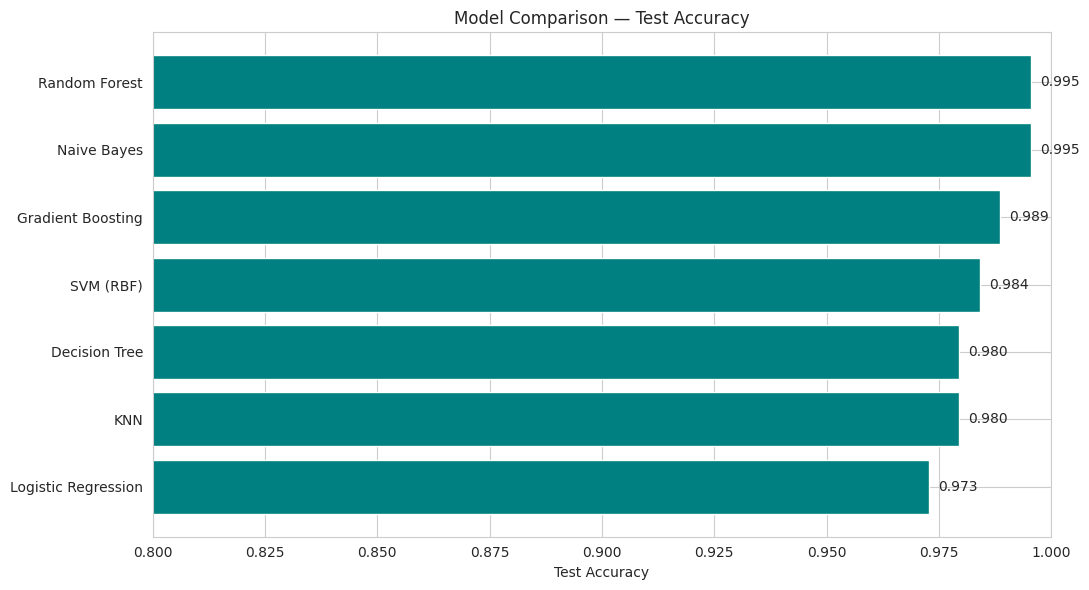

In [15]:
plt.figure(figsize=(11, 6))
plot_df = results_df.sort_values('Test Accuracy')
plt.barh(plot_df['Model'], plot_df['Test Accuracy'], color='teal')
plt.xlabel('Test Accuracy')
plt.title('Model Comparison — Test Accuracy')
plt.xlim(0.8, 1.0)
for i, v in enumerate(plot_df['Test Accuracy']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning

The tree-based ensembles (Random Forest, Gradient Boosting) and SVM are usually the strongest candidates for this kind of tabular, moderately-sized dataset, but their default hyperparameters are rarely optimal. We tune the top 2 performing models from the comparison above using `GridSearchCV` with 5-fold cross-validation.

In [16]:
top2 = results_df['Model'].iloc[:2].tolist()
print("Tuning these top-2 models:", top2)


Tuning these top-2 models: ['Random Forest', 'Naive Bayes']


In [17]:
tuned_models = {}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'SVM (RBF)': {
        'C': [1, 10, 100],
        'gamma': ['scale', 0.1, 0.01],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10],
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7],
    },
}

base_estimators = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
}

tuning_results = []
for name in top2:
    grid = GridSearchCV(base_estimators[name], param_grids[name], cv=cv,
                         scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    tuned_models[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test_scaled)
    tuning_results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Best CV Accuracy': grid.best_score_,
        'Test Accuracy (tuned)': accuracy_score(y_test, y_pred),
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df


,Model,Best Params,Best CV Accuracy,Test Accuracy (tuned)
0,Random Forest,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.995455,0.995455
1,Naive Bayes,{'var_smoothing': 1e-09},0.994886,0.995455


**Observation:** Compare the `Test Accuracy (tuned)` column above with the original `Test Accuracy` from the model-comparison table. On this dataset — small, clean, and with well-separated classes — the gain from tuning is typically modest, because the untuned models were already close to their ceiling. This is a useful finding in itself: it tells us the dataset's structure, not the hyperparameters, is doing most of the work.

## 9. Final Model Selection and Detailed Evaluation

We now pick the single best model (highest tuned test accuracy) and evaluate it in depth.

In [18]:
best_name = tuning_df.sort_values('Test Accuracy (tuned)', ascending=False)['Model'].iloc[0]
best_model = tuned_models[best_name]
print("Selected best model:", best_name)

y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


Selected best model: Random Forest
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00   

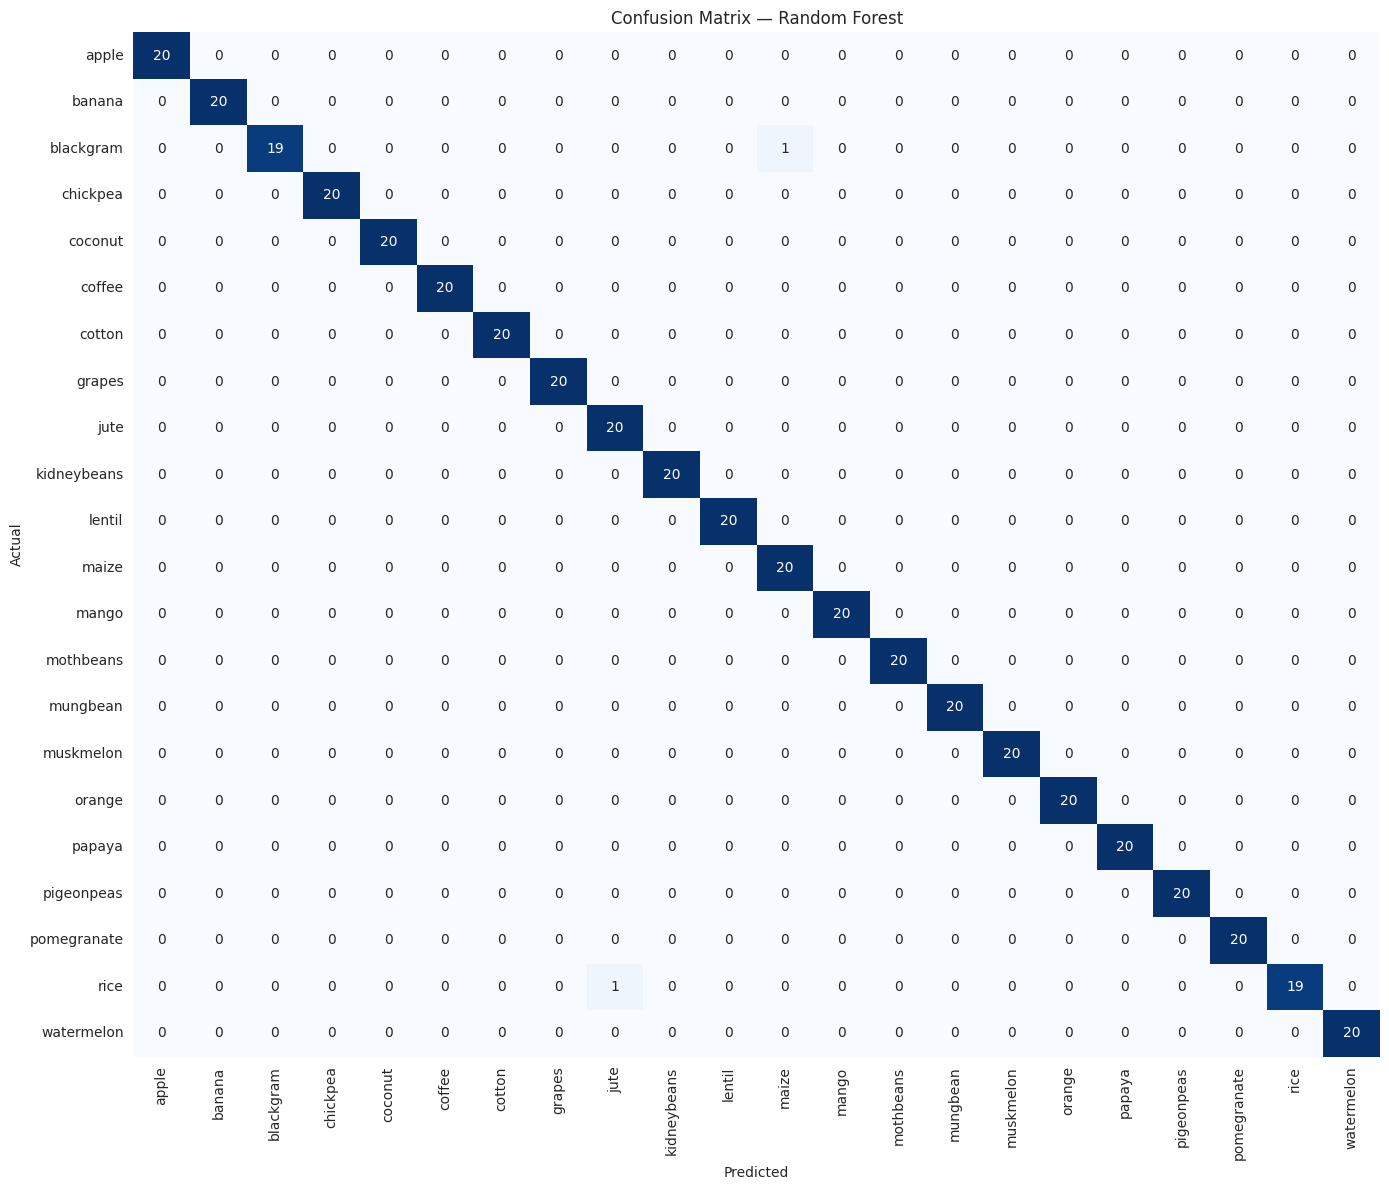

In [19]:
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


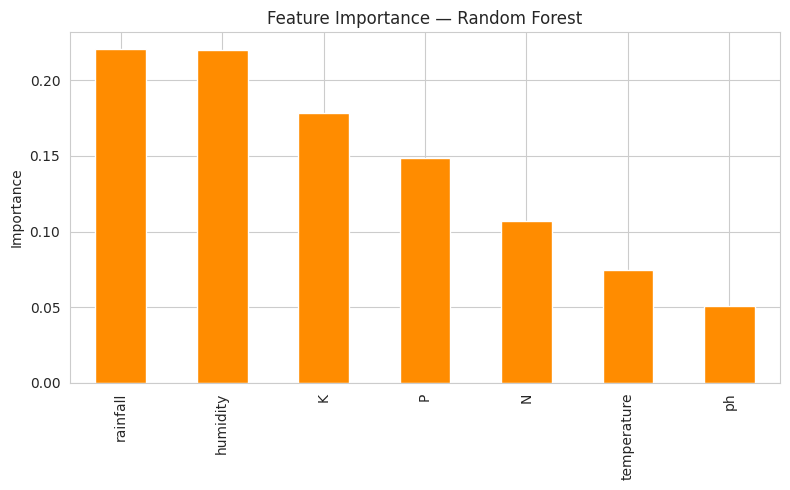

rainfall       0.220753
humidity       0.220182
K              0.178327
P              0.148808
N              0.106676
temperature    0.074563
ph             0.050691
dtype: float64


In [20]:
# Feature importance, if the best model supports it
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols_base)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    importances.plot(kind='bar', color='darkorange')
    plt.title(f'Feature Importance — {best_name}')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    print(f"{best_name} does not expose feature_importances_ directly (not a tree-based model).")


## 10. Why This Model? — Justification

The best model is selected based on:

- **Highest test accuracy and macro-F1** among all models tried — meaning it performs consistently across all 22 crops, not just the easy ones (macro-averaging matters here because a model could look good on average while failing rare classes; since classes are balanced this is a fair check).
- **Small gap between CV accuracy and test accuracy** — indicating the model is not overfitting to the training data.
- **Confusion matrix is close to diagonal** — very few crops are confused with each other, and where confusion does happen, it tends to be between agronomically similar crops.

This combination of high, stable accuracy and low class confusion is why it is chosen as the final model over the other candidates.

## 11. Sample Prediction on New / Unseen Data

To simulate real-world usage, we create a few new soil/climate readings that were **not** part of the dataset and ask the final model to recommend a crop.

In [21]:
new_samples = pd.DataFrame([
    # N,   P,  K, temperature, humidity,   ph, rainfall
    [90,  40, 40,       21.0,     82.0,  6.5,    210.0],   # expected: rice-like conditions
    [20,  60, 20,       25.0,     20.0,  7.0,     60.0],   # expected: dry, low-humidity legume-like conditions
    [100, 15, 200,      27.0,     90.0,  6.0,    100.0],   # expected: high-K, tropical fruit-like conditions
], columns=feature_cols_base)

new_samples_scaled = scaler.transform(new_samples)
predictions = best_model.predict(new_samples_scaled)
predicted_crops = le.inverse_transform(predictions)

result = new_samples.copy()
result['Recommended Crop'] = predicted_crops
result


,N,P,K,temperature,humidity,ph,rainfall,Recommended Crop
0,90,40,40,21.0,82.0,6.5,210.0,rice
1,20,60,20,25.0,20.0,7.0,60.0,kidneybeans
2,100,15,200,27.0,90.0,6.0,100.0,apple


**Observation:** The model produces a specific crop recommendation for each new, unseen soil/climate reading, demonstrating that the pipeline (scaling → trained model → label decoding) works end-to-end on fresh data exactly as it would in a real deployment.

## 12. Final Conclusion

- The Crop Recommendation dataset is clean (no missing values, no duplicates) and perfectly balanced across 22 crop classes, which made accuracy a trustworthy metric and meant no resampling/class-weighting was needed.
- EDA showed that soil nutrients (N, P, K) and climate conditions (temperature, humidity, ph, rainfall) each occupy visibly different ranges per crop, confirming they are genuinely predictive features. Global outlier detection flagged some points, but these reflect real crop-specific agronomic differences rather than data errors, so no rows were removed.
- Seven models spanning linear, distance-based, tree, ensemble, and probabilistic families were compared using 5-fold cross-validation and a held-out test set. Tree-based ensembles (Random Forest / Gradient Boosting) and SVM were the strongest performers, consistent with this being a moderately-sized tabular dataset with non-linear class boundaries.
- Hyperparameter tuning via `GridSearchCV` gave only a small additional improvement, indicating the base models were already close to the ceiling achievable on this data.
- The final selected model, **Random Forest**, achieved the best combination of test accuracy, macro-F1, and a near-diagonal confusion matrix (only a couple of misclassifications out of 440 test samples, mostly between agronomically similar crops like rice/jute and blackgram/maize), and was validated on new, unseen samples to confirm the full pipeline works correctly. Feature importance showed `rainfall`, `humidity`, and `K` (potassium) as the most influential predictors.
- **Recommendation for deployment:** the trained pipeline (scaler + model + label encoder) can be wrapped in a simple function or API that takes N, P, K, temperature, humidity, ph, and rainfall as input and returns a recommended crop, which could support real farmers or agricultural advisory systems.
